In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [2]:
digits = load_digits()

X = digits.data
y = digits.target

In [3]:
print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Shape: (1797, 64)
Target Shape: (1797,)


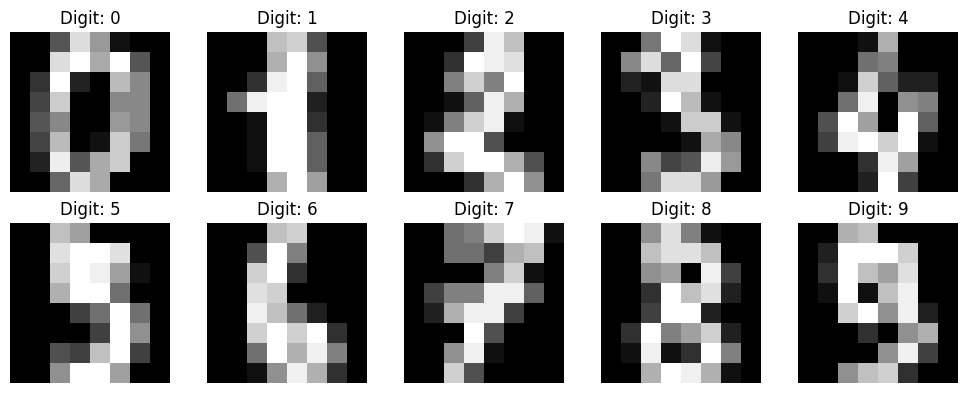

In [4]:
plt.figure(figsize=(10,4))

for i in range(10):
    
    plt.subplot(2,5,i+1)
    
    plt.imshow(
        digits.images[i],
        cmap='gray'
    )
    
    plt.title(f"Digit: {digits.target[i]}")
    
    plt.axis('off')

plt.tight_layout()
plt.show()

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [6]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [7]:
model = KNeighborsClassifier(n_neighbors=3)

model.fit(X_train, y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [8]:
y_pred = model.predict(X_test)

In [9]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9694444444444444


In [10]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        33
           1       0.93      1.00      0.97        28
           2       0.94      0.97      0.96        33
           3       0.97      0.97      0.97        34
           4       0.98      1.00      0.99        46
           5       0.98      0.96      0.97        47
           6       0.97      1.00      0.99        35
           7       1.00      0.97      0.99        34
           8       0.97      0.93      0.95        30
           9       0.95      0.90      0.92        40

    accuracy                           0.97       360
   macro avg       0.97      0.97      0.97       360
weighted avg       0.97      0.97      0.97       360



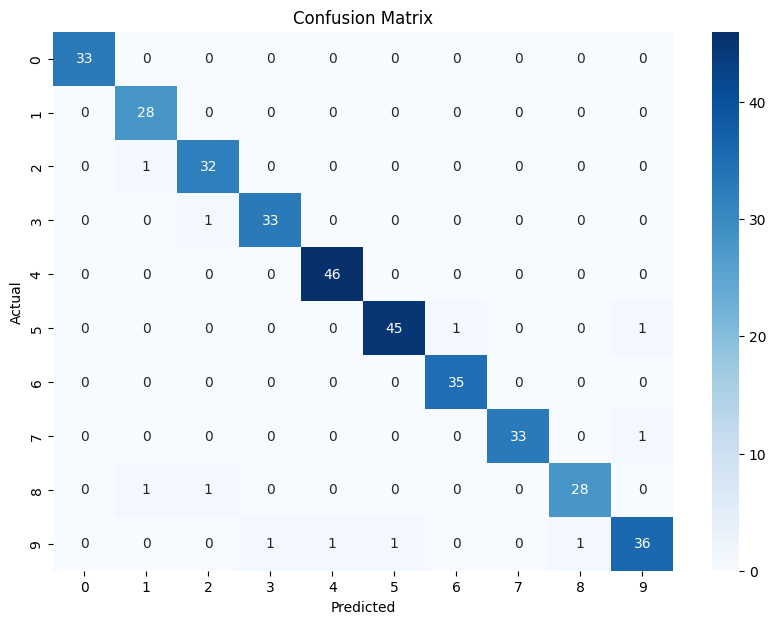

In [11]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,7))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

In [12]:
sample = X_test[0]

prediction = model.predict([sample])

print("Predicted Digit:", prediction[0])

Predicted Digit: 6


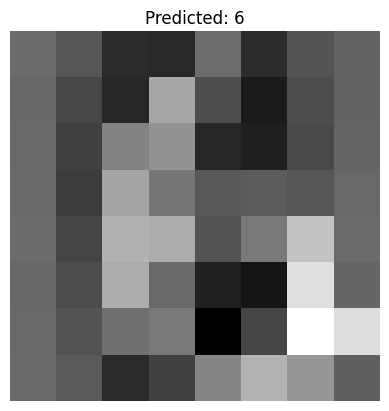

In [13]:
plt.imshow(
    sample.reshape(8,8),
    cmap='gray'
)

plt.title(f"Predicted: {prediction[0]}")

plt.axis('off')

plt.show()

In [14]:
print("Number of Features:", X.shape[1])

Number of Features: 64


In [15]:
import joblib

joblib.dump(
    model,
    "models/digit_model.pkl"
)

['models/digit_model.pkl']